# Donut Fine-Tuned Model Test — `pipeline` 버전

`naver-clova-ix/donut-base-finetuned-cord-v2` 모델로 CORD-v2(영수증 파싱)를 테스트합니다.

이 노트북은 `donut_CORD_v2_fine_tunned_test.ipynb` 의 **수동 추론 코드**(`decoder_input_ids`
구성 → `model.generate()` → 특수토큰 정규식 제거 → 직접 만든 `token2json`)를
HuggingFace **`pipeline`** 한 줄 호출로 바꾼 버전입니다.

> 🔹 Python/PyTorch/CUDA 환경 및 GPU 정보 출력

In [1]:
import sys, torch
print(f"Python: {sys.version}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Python: 3.10.19 (main, Oct 21 2025, 16:38:01) [GCC 11.2.0]
PyTorch: 2.11.0+cu130
CUDA available: True
GPU: NVIDIA GB10


> 🔹 필요 라이브러리(transformers pipeline, datasets, torch, matplotlib) import

In [ ]:
from transformers import pipeline
from transformers.utils import logging as hf_logging
hf_logging.disable_progress_bar()

from datasets import load_dataset
import torch, json
import matplotlib.pyplot as plt

## 수동 추론 vs `pipeline`

이전 노트북은 추론 과정을 단계별로 직접 구현해 **내부 동작을 학습**하는 데 목적이 있었습니다.
이 노트북은 같은 결과를 `pipeline` 으로 **간결하게** 얻습니다. 출력 JSON은 동일합니다.

| 단계 | 수동 버전 (`..._test.ipynb`) | pipeline 버전 (이 노트북) |
|------|------------------------------|----------------------------|
| 모델/프로세서 로드 | `DonutProcessor` + `VisionEncoderDecoderModel` 각각 | `pipeline(...)` 한 번 |
| 이미지 전처리 | `processor(image)` 로 `pixel_values` | pipeline 내부 자동 |
| 태스크 토큰 주입 | `decoder_input_ids` 수동 구성 | `{"text": "<s_cord-v2>"}` 전달 |
| 생성 | `model.generate(...)` (옵션 다수) | pipeline 내부 자동 |
| 특수토큰 제거 | `replace` + `re.sub(r"<.*?>", ...)` | pipeline 내부 자동 |
| 토큰→JSON | 직접 구현한 `token2json` | `processor.token2json` 내장 사용 |

> transformers 5.x에서 기존 `image-to-text` 태스크는 제거되고 **`image-text-to-text`** 로
> 통합되었습니다. 이 태스크는 `VisionEncoderDecoder`(Donut 구조)를 지원하므로
> 영수증 파싱 모델을 그대로 사용할 수 있습니다.

## Base Model vs Fine-tuned Model

### Base Model (`donut-base`)
대량의 문서 이미지로 **일반적인 패턴**을 학습한 모델

모델 페이지: https://huggingface.co/naver-clova-ix/donut-base

- 약 1,100만(11M) 장의 영문 스캔 문서 이미지 (담배 소송 관련 공개 문서 모음).
- 정답 텍스트 라벨이 없으므로, 상용 OCR 엔진으로 pseudo-label(읽기 순서대로의
  텍스트)을 만들어 학습 타깃으로 사용.
- 주로 영어 위주, 실제 노이즈가 많은 스캔 품질을 학습.

#### pseudo-label 이 뭐고, 왜 쓰나? (핵심)

- 지도학습엔 `이미지 → 정답 텍스트` 쌍이 필요한데, 1,100만 장에 사람이 적어둔 정답이 **없음**.
  사람이 일일이 전사하는 건 비용·시간상 불가능.
- 그래서 **상용 OCR 로 텍스트를 자동 추출** → 이 "가짜 정답"을 학습 타깃으로 씀. 이게 **pseudo-label**.
  ("읽기 순서대로" = OCR 이 글자 위치를 기준으로 왼→오, 위→아래 사람이 읽는 순서로 정렬)
- 목표가 "완벽한 정답"이 아니라 **"이미지에서 글자를 읽는 능력"** 학습이라,
  OCR 이 일부 틀려도 대규모 학습으로 충분히 "읽는 눈"을 얻음.

| 단계 | 정답 출처 | 배우는 것 |
|------|-----------|-----------|
| **사전학습** (base) | OCR pseudo-label (가짜 정답) | 글자 읽기 |
| **파인튜닝** (cord-v2) | 사람이 만든 진짜 JSON | 영수증 → JSON |

| 항목 | 내용 |
|------|------|
| 학습 데이터 | IIT-CDIP (1100만 장의 다양한 문서 이미지) |
| 학습 목표 | 이미지에서 텍스트를 읽는 능력 자체를 익힘 |
| 결과 | 문서를 "보고 이해"할 수 있지만 특정 태스크는 모름 |

### Fine-tuned Model (`donut-base-finetuned-cord-v2`)
Huggingface 데이터셋 다운로드 : https://huggingface.co/datasets/naver-clova-ix/cord-v2

Base Model을 출발점으로, **특정 태스크 데이터**로 추가 학습한 모델

| 항목 | 내용 |
|------|------|
| 학습 데이터 | CORD-v2 (영수증 800장 + 정답 JSON) |
| 학습 목표 | 영수증 → `gt_parse` JSON 구조로 변환 |
| 결과 | 영수증 파싱에 특화된 능력 보유 |

### 비유

```
Base Model   = 대학 졸업생  (읽기·이해력은 갖춤, 전문 업무는 아직 모름)
Fine-tuning  = 입사 후 실무 교육  (영수증 처리 업무만 집중 훈련)
Fine-tuned   = 영수증 처리 전문 직원  (영수증 → JSON 즉시 변환 가능)
```

## pipeline 생성

`pipeline("image-text-to-text", ...)` 한 번으로 모델 + 프로세서 + 전처리/후처리 파이프라인이
구성됩니다. `device=0` 은 첫 번째 GPU, `-1` 은 CPU를 의미합니다.

> 🔹 HF pipeline(image-text-to-text)로 CORD-v2 파인튜닝 모델 로드

In [3]:
model_name = "naver-clova-ix/donut-base-finetuned-cord-v2"
device = 0 if torch.cuda.is_available() else -1

# image-text-to-text: 이미지 + 텍스트(태스크 토큰)를 받아 토큰 시퀀스를 생성하는 태스크.
# 전처리(resize/normalize) → generate → 특수토큰 제거까지 내부에서 처리한다.
pipe = pipeline("image-text-to-text", model=model_name, device=device)

# token2json 변환에 쓸 프로세서 참조 (pipe.processor 와 동일 객체)
processor = pipe.processor
print(f"pipeline ready on {'cuda' if device == 0 else 'cpu'} | processor: {type(processor).__name__}")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Device set to use cuda:0


pipeline ready on cuda | processor: DonutProcessor


/home/jhkim/anaconda3/envs/kardi_env/lib/python3.10/site-packages/transformers/models/donut/processing_donut.py:205: FutureWarning: `feature_extractor` is deprecated and will be removed in v5. Use `image_processor` instead.
  warnings.warn(


## CORD-v2 Dataset 구조

영수증 이미지 + JSON 어노테이션으로 구성된 문서 파싱 벤치마크 데이터셋

### Splits

| Split      | 샘플 수 |
|------------|--------|
| train      | 800    |
| validation | 100    |
| test       | 100    |

### 컬럼

| 컬럼명          | 타입        | 설명                      |
|----------------|-------------|---------------------------|
| `image`        | PIL Image   | 영수증 이미지              |
| `ground_truth` | JSON string | 레이블 + 메타 정보 전체    |

### `ground_truth` JSON 구조 (요약)

```
ground_truth
├── gt_parse              ← Donut 학습에 사용하는 핵심 레이블
│   ├── menu []           ← 주문 항목 목록 (nm, cnt, price, unitprice ...)
│   ├── sub_total         ← 소계 영역 (subtotal_price, tax_price ...)
│   └── total             ← 합계 영역 (total_price, cashprice ...)
├── meta                  ← image_id, image_size, split 등 메타 정보
└── valid_line []         ← 단어별 바운딩 박스 (OCR 전용, Donut 미사용)
```

> Donut은 `gt_parse` 만 사용하며, `valid_line` / `roi` 등은 다른 OCR 모델용 어노테이션입니다.

> 🔹 CORD-v2 테스트셋 첫 샘플 로드 후 이미지·정답(gt_parse) 표시

Dataset({
    features: ['image', 'ground_truth'],
    num_rows: 1
})
샘플 수: 1, 컬럼 수: 2

=== 이미지 정보 ===
크기: (432, 648)  모드: RGB

=== gt_parse 내용 ===
{
  "menu": {
    "nm": "-TICKET CP",
    "num": "901016",
    "cnt": "2",
    "price": "60.000",
    "itemsubtotal": "60.000"
  },
  "sub_total": {
    "subtotal_price": "60.000",
    "discount_price": "-60.000",
    "tax_price": "5.455"
  },
  "total": {
    "total_price": "60.000",
    "creditcardprice": "60.000",
    "menuqty_cnt": "2.00"
  }
}


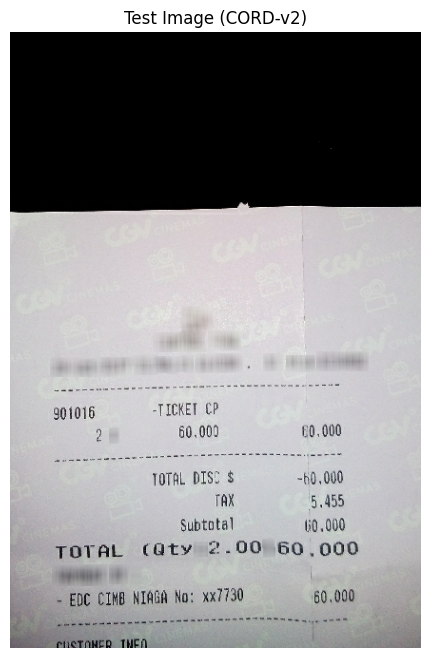

In [4]:
# CORD-v2: 영수증 이미지 + JSON 어노테이션 데이터셋
# test[:1] → 테스트셋 첫 번째 샘플 1장만 로드
dataset = load_dataset("naver-clova-ix/cord-v2", split="test[:1]")
print(dataset)
print(f"샘플 수: {len(dataset)}, 컬럼 수: {len(dataset.features)}")

image = dataset[0]["image"]
ground_truth = json.loads(dataset[0]["ground_truth"])

print("\n=== 이미지 정보 ===")
print(f"크기: {image.size}  모드: {image.mode}")

print("\n=== gt_parse 내용 ===")
print(json.dumps(ground_truth["gt_parse"], indent=2, ensure_ascii=False))

plt.figure(figsize=(6, 8))
plt.imshow(image)
plt.axis("off")
plt.title("Test Image (CORD-v2)")
plt.show()

## 추론 (Inference) — pipeline 호출

`pipe({"images": ..., "text": ...})` 한 번으로 추론이 끝납니다.

- `text="<s_cord-v2>"` : 태스크 토큰. pipeline이 디코더 시작 입력으로 넣어줍니다.
- `return_full_text=False` : 출력에서 입력 태스크 토큰을 제거하고 생성분만 반환.
- `max_new_tokens=512` : 모델 기본 `max_length=20` 은 너무 짧으므로 충분히 늘려줍니다.

반환 형식은 `[{"input_text": ..., "generated_text": ...}]` 이며,
`generated_text` 가 `<s_menu>...</s_total>` 형태의 XML 토큰 시퀀스입니다.

> 🔹 pipeline에 이미지와 태스크 토큰을 입력해 원시 출력 생성

In [5]:
task_prompt = "<s_cord-v2>"

result_text = pipe(
    {"images": image, "text": task_prompt},
    max_new_tokens=512,
    return_full_text=False,
)[0]["generated_text"]

print("Raw output:", result_text)

Raw output: <s_menu><s_nm> - TICKET CP</s_nm><s_num> 901016</s_num><s_unitprice> 60.000</s_unitprice><s_cnt> 2</s_cnt><s_price> 60,000</s_price></s_menu><s_sub_total><s_subtotal_price> -60.000</s_subtotal_price><s_tax_price> 5,455</s_tax_price></s_sub_total><s_total><s_total_price> 60.000</s_total_price><s_emoneyprice> 60.000</s_emoneyprice><s_menuqty_cnt> 2.00</s_menuqty_cnt></s_total>


### 토큰 시퀀스 → JSON

수동 버전에서는 `token2json` 을 직접 구현했지만, `DonutProcessor` 에 동일한 기능이
**내장**되어 있습니다. `<s_key>값</s_key>` 패턴을 재귀적으로 파싱해 dict로 만듭니다.

> 🔹 프로세서 내장 token2json으로 출력 토큰을 dict로 파싱

In [6]:
# DonutProcessor 내장 token2json 사용 (직접 구현한 함수와 동일 동작)
result = processor.token2json(result_text)

print("Parsed result:")
print(json.dumps(result, indent=2, ensure_ascii=False))

Parsed result:
{
  "menu": {
    "nm": "- TICKET CP",
    "num": "901016",
    "unitprice": "60.000",
    "cnt": "2",
    "price": "60,000"
  },
  "sub_total": {
    "subtotal_price": "-60.000",
    "tax_price": "5,455"
  },
  "total": {
    "total_price": "60.000",
    "emoneyprice": "60.000",
    "menuqty_cnt": "2.00"
  }
}


> 🔹 데이터셋 정답(gt_parse)과 모델 예측 결과 비교 출력

In [7]:
# 데이터셋 정답(gt_parse)과 모델 예측 비교
print("=== Ground Truth (gt_parse) ===")
print(json.dumps(ground_truth["gt_parse"], indent=2, ensure_ascii=False))
print("\n=== Prediction ===")
print(json.dumps(result, indent=2, ensure_ascii=False))

=== Ground Truth (gt_parse) ===
{
  "menu": {
    "nm": "-TICKET CP",
    "num": "901016",
    "cnt": "2",
    "price": "60.000",
    "itemsubtotal": "60.000"
  },
  "sub_total": {
    "subtotal_price": "60.000",
    "discount_price": "-60.000",
    "tax_price": "5.455"
  },
  "total": {
    "total_price": "60.000",
    "creditcardprice": "60.000",
    "menuqty_cnt": "2.00"
  }
}

=== Prediction ===
{
  "menu": {
    "nm": "- TICKET CP",
    "num": "901016",
    "unitprice": "60.000",
    "cnt": "2",
    "price": "60,000"
  },
  "sub_total": {
    "subtotal_price": "-60.000",
    "tax_price": "5,455"
  },
  "total": {
    "total_price": "60.000",
    "emoneyprice": "60.000",
    "menuqty_cnt": "2.00"
  }
}


> 🔹 입력 이미지와 파싱 결과(JSON)를 나란히 시각화

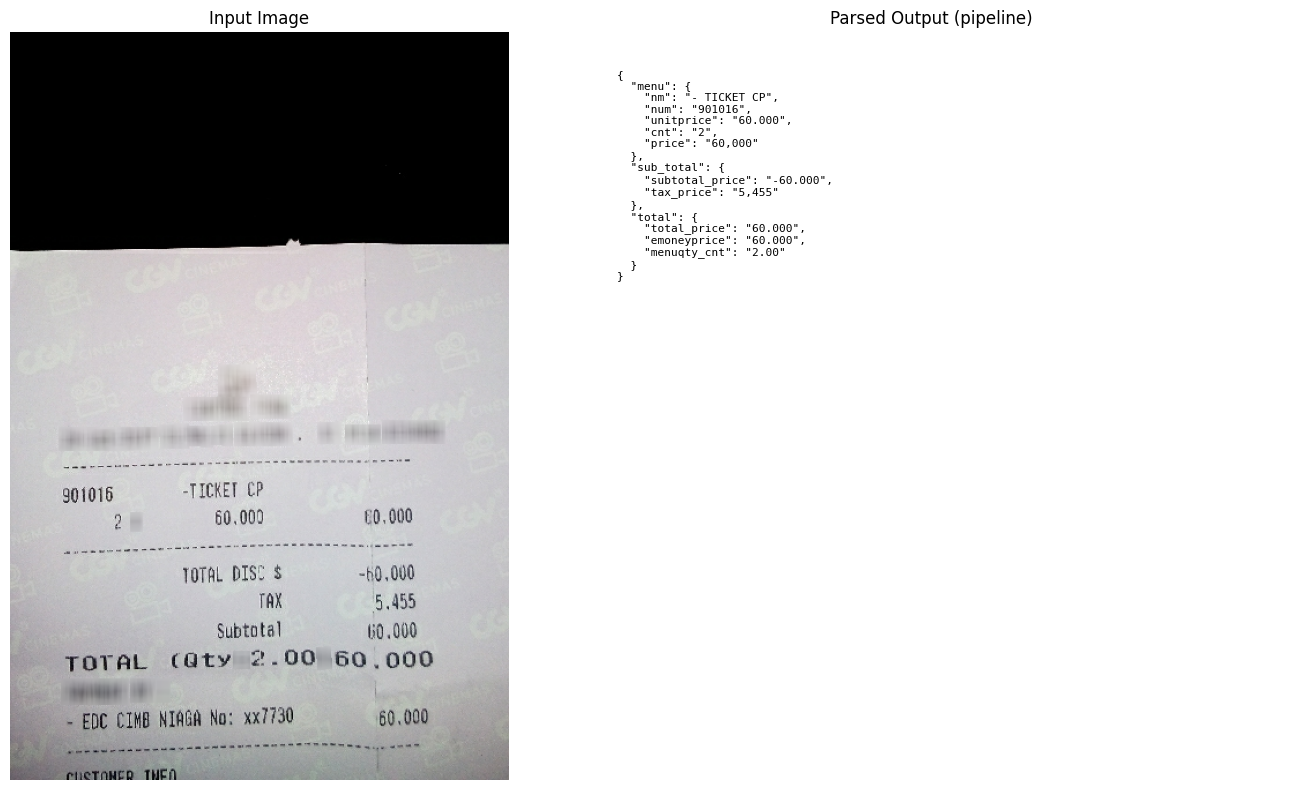

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

axes[0].imshow(image)
axes[0].axis("off")
axes[0].set_title("Input Image")

axes[1].axis("off")
axes[1].set_title("Parsed Output (pipeline)")
axes[1].text(
    0.05, 0.95,
    json.dumps(result, indent=2, ensure_ascii=False),
    transform=axes[1].transAxes,
    fontsize=8,
    verticalalignment="top",
    fontfamily="monospace",
)

plt.tight_layout()
plt.show()